The companion library is a machine-learning tool that uses a quantum device to predict similarities and properties of graphs. In this tutorial, we will reproduce first part of the QEK paper using the library's high-level API. The high-level goal of this tutorial is to predict toxicity properties of molecules, using quantum machine learning, but of course, the mechanisms involved are much more generic.

By the end of this notebook, you will know how to:

-Setup import for a molecular dataset (the library supports other type of graphs, of course).

-Setup compilation and execution of these graphs for execution on a Quantum Device (either an emulator or a physical QPU).

-Launch the execution and extract the relevant machine-learning features.


In [1]:
pip install quantum-evolution-kernel

Note: you may need to restart the kernel to use updated packages.


Dataset preparation


As in any machine learning task, we first need to load and prepare data. QEK can work with many types of graphs, including molecular graphs. For this tutorial, we will use the PTC-FM dataset, which contains such molecular graphs, labeled with their toxicity.



In [15]:
import torch_geometric.datasets as pyg_dataset

from qek.shared.retrier import PygRetrier

# Load the original PTC-FM dataset.
# We use PygRetrier to retry the download if it fails.
og_ptcfm = PygRetrier().insist(pyg_dataset.TUDataset, root="dataset", name="PTC_FM")

display("Loaded %s samples" % (len(og_ptcfm), ))

'Loaded 349 samples'

To extract machine-learning features from our dataset, we will need to configure a feature extractor. This library provides several feature extractors to either make use of a physical quantum device (QPU), or a variety of emulators.

To configure a feature extractor, we will need to provide a compiler, whose task is to take a list of graphs, extract embeddings and compile these embeddings to sequences of pulses, the format that can be executed by either a QPU or an emulator. For this tutorial, our dataset is composed of molecule graphs following the PTCFM conventions, so we will use the PTCFMCompiler:

In [16]:
import qek.data.graphs as qek_graphs

compiler = qek_graphs.PTCFMCompiler()

This library also provides other compilers from a variety of graph formats.

The easiest way to process a graph is to compile and execute it for an emulator. QEK is built on top of Pulser, which provides several emulators. The simplest of these emulators is the QutipEmulator, which QEK uses for the QutipExtractor:

In [17]:
from pathlib import Path
import qek.data.extractors as qek_extractors

# Use the Qutip Extractor.
extractor = qek_extractors.QutipExtractor(
    # Once computing is complete, data will be saved in this file.
    path=Path("saved_data.json"),
    compiler=compiler
)

# Add the graphs using the compiler we've picked previously.
extractor.add_graphs(graphs=og_ptcfm)

# We may now compile them.
compiled = extractor.compile()
display("Compiled %s sequences" % (len(compiled), ))

graph # 2 is not embeddable, skipping
graph # 17 is not embeddable, skipping
graph # 24 is not embeddable, skipping
graph # 26 is not embeddable, skipping
graph # 27 is not embeddable, skipping
graph # 35 is not embeddable, skipping
graph # 41 is not embeddable, skipping
graph # 44 is not embeddable, skipping
graph # 59 is not embeddable, skipping
graph # 61 is not embeddable, skipping
graph # 63 is not embeddable, skipping
graph # 66 is not embeddable, skipping
graph # 87 is not embeddable, skipping
graph # 102 is not embeddable, skipping
graph # 105 is not embeddable, skipping
graph # 108 is not embeddable, skipping
graph # 116 is not embeddable, skipping
graph # 119 is not embeddable, skipping
graph # 123 is not embeddable, skipping
graph # 127 is not embeddable, skipping
graph # 129 is not embeddable, skipping
graph # 130 is not embeddable, skipping
graph # 133 is not embeddable, skipping
graph # 136 is not embeddable, skipping
graph # 156 is not embeddable, skipping
graph # 167 is

/opt/anaconda3/lib/python3.12/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will be

'Compiled 285 sequences'

As you can see, the number of sequences compiled is lower than the number of samples loaded. Some of this is due to limitations within the algorithm (not all graphs can be efficiently laid out for execution on a Quantum Device), while others are due to the limitations of the emulator we target.

We may now run the extraction on the emulator:

In [18]:
# Limit the number of qubits for this run, for performance reasons.
# You can increase this value to higher number of qubits, but this
# notebook will take longer to execute and may run out of memory.
#
# On our test computer, the practical limit is around 10 qubits.

#Strongly encourages you to vary the number of qubit an rerun the two notebooks to see differences!
#
max_qubits = 5
processed_dataset = extractor.run(max_qubits=max_qubits).processed_data
display("Extracted features from %s samples"% (len(processed_dataset), ))

Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (20 > 5), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (16 > 5), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (11 > 5), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (19 > 5), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (16 > 5), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (18 > 5), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (11 > 5), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (8 > 5), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (22 > 5), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (16 > 5), skipping
G

/opt/anaconda3/lib/python3.12/site-packages/pulser/register/register.py:552: UserWarning: Register serialization to an abstract representation irreversibly converts all qubit ID's to strings.
  names = stringify_qubit_ids(self._ids)


processed data saved to saved_data.json


'Extracted features from 40 samples'

If you wish to extract features from more samples, feel free to increase the value of MAX_QUBITS above. However, you will soon run into limitations of a quantum emulator, and possibly crash this notebook. At this point, you have other options, such as using EmuMPSExtractor instead of QutipExtractor, a more recent emulator that features much better performance in most cases, or you can run the extraction on a physical QPU.

WITH A REAL QPU

Once you have checked that low qubit sequences provide the results you expect on an emulator, you will generally want to move to a QPU. For this, you will need either physical access to a QPU, or an account with PASQAL Cloud, which provides you remote access to QPUs built and hosted by Pasqal. In this section, we'll see how to use the latter.

If you don't have an account, just skip to the next section!

In [ ]:
from pathlib import Path


HAVE_PASQAL_ACCOUNT = False # If you have a PASQAL Cloud account, fill in the details and set this to `True`.

if HAVE_PASQAL_ACCOUNT:
    # Use the QPU Extractor.
    extractor = qek_extractors.RemoteQPUExtractor(
        # Once computing is complete, data will be saved in this file.
        path=Path("saved_data.json"),
        compiler = compiler,
        project_id = "XXXX", # Replace this with your project id on the PASQAL Cloud
        username = "XXX",    # Replace this with your username on PASQAL Cloud
        password = None,     # Replace this with your password on PASQAL Cloud or enter it on the command-line
    )

    # Add the graphs, exactly as above.
    extractor.add_graphs(graphs=og_ptcfm)

    # We may now compile, exactly as above.
    compiled = extractor.compile()
    display("Compiled %s sequences" % (len(compiled), ))

    # Launch the execution.
    extracted = extractor.run()
    display("Work enqueued with ids %s" % (extractor.batch_ids, ))

    # ...and wait for the results.
    await extracted
    processed_data = extracted.processed_data
    display("Extracted features from %s samples"% (len(processed_data), ))

As you can see, the process is essentially identical to executing with an emulator. Note that, as of this writing, the waiting line to access a QPU can be very long (typically several hours).

There are two main ways to deal with this:

RemoteQPUExtractor can be attached to an ongoing job from batch ids, so that you can resume your work e.g. after turning off your computer.
Pasqal CLOUD offers access to high-performance hardware-based emulators, with dramatically shorter waiting lines. For instance, in the snippet above, you may replace RemoteQPUExtractor with RemoteEmuMPSExtractor to use the emu-mps emulator.

I am not sure how it will be adressed for the Ruby machine.


For this notebook, instead of spending hours running the simulator on your computer, we're going to skip this step and load on we're going to cheat and load the results, which are conveniently stored in ptcfm_processed_dataset.json.

In [14]:
#If you want to replicate on a jupyter notebook use this snippet to get the path where you are
#and plug it into next cell with /saved_data.json at the end.

import os
cwd = os.getcwd()
print(cwd)

/Users/vincent.martin/Library/CloudStorage/OneDrive-PASQALSAS/Bureau/Scripts python/Travail/Material science and QML webinar (formation GENCI 5)


In [19]:
 import qek.data.processed_data as qek_dataset
processed_dataset = qek_dataset.load_dataset(file_path="/Users/vincent.martin/Library/CloudStorage/OneDrive-PASQALSAS/Bureau/Scripts python/Travail/Material science and QML webinar (formation GENCI 5)/saved_data.json")
print(f"Size of the quantum compatible dataset = {len(processed_dataset)}")

Size of the quantum compatible dataset = 40


We can check the geometry for one of the samples:

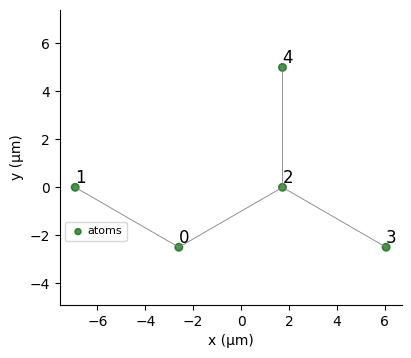

In [20]:
dataset_example = processed_dataset[23]
dataset_example.draw_register()

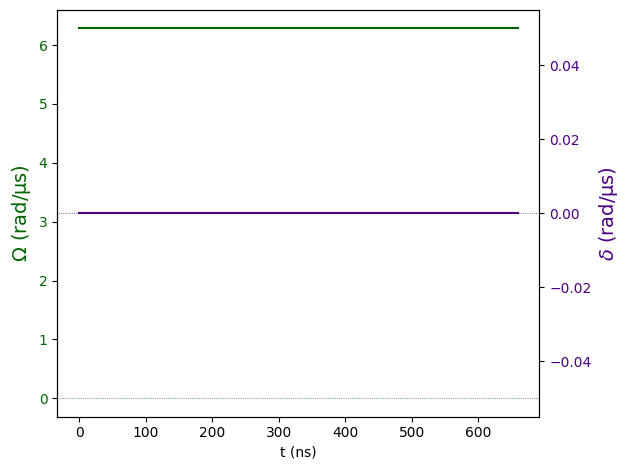

In [21]:
dataset_example.draw_pulse()

The results of executing the embedding on the Quantum Device are in field state_dict:

In [22]:
display(dataset_example.state_dict)
print(f"Total number of samples: {sum(dataset_example.state_dict.values())}")

{'01000': 5,
 '00001': 180,
 '00010': 211,
 '01001': 84,
 '00011': 76,
 '01010': 104,
 '00000': 111,
 '01100': 48,
 '00100': 53,
 '10001': 25,
 '10010': 22,
 '10011': 32,
 '01011': 23,
 '10000': 25,
 '01110': 1}

Total number of samples: 1000


This dictionary represents an approximation of the quantum state of the device for this graph after completion of the algorithm.

each of the keys represents one possible state for the register (which represents the graph), with each qubit (which represents a single node) being in state 0 or 1;
the corresponding value is the number of samples observed with this specific state of the register.


Note: Since Quantum Devices are inherently non-deterministic, you will probably obtained different samples if you run this on a Quantum Device instead of loading the dataset.



From the state dictionary, we derive as machine-learning feature the distribution of excitation. We'll use this in a second to define our kernel.

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


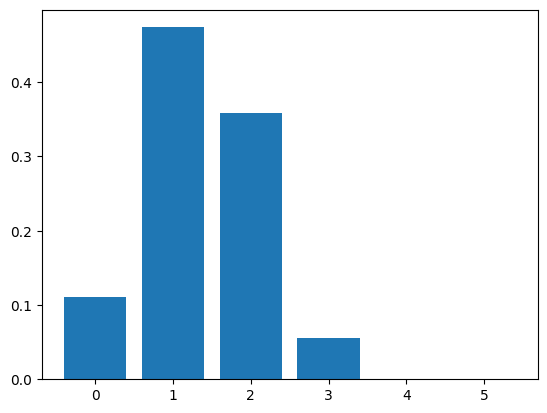

In [23]:
dataset_example.draw_excitation()

Is this distribution of excitation connected to the toxicity of the molecule? To check this out, we'll need to perform some machine-learning engineering.

Note Of course, you could derive features completely unrelated to distribution of excitation.